In [0]:
# ==================================
# 03 - Exploratory Data Analysis
# ==================================


from pyspark.sql import functions as F
import matplotlib.pyplot as plt

# -------------------------
# 1. Paths
# -------------------------
storage_account = "projecttraffic60302085"
spark.conf.set(
 f"fs.azure.account.key.{storage_account}.dfs.core.windows.net",
 ""
)
processed_path = f"abfss://processed@{storage_account}.dfs.core.windows.net/accidents/"
curated_path = f"abfss://curated@{storage_account}.dfs.core.windows.net/accidents_features_v1/"

In [0]:
df = spark.read.parquet(curated_path)

print("Rows:", df.count())
print("Columns:", len(df.columns))
df.printSchema()
display(df.limit(5))

Rows: 7554935
Columns: 51
root
 |-- ID: string (nullable = true)
 |-- Source: string (nullable = true)
 |-- Severity: integer (nullable = true)
 |-- Start_Time: timestamp (nullable = true)
 |-- End_Time: timestamp (nullable = true)
 |-- Start_Lat: double (nullable = true)
 |-- Start_Lng: double (nullable = true)
 |-- End_Lat: double (nullable = true)
 |-- End_Lng: double (nullable = true)
 |-- Distancemi: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Timezone: string (nullable = true)
 |-- Airport_Code: string (nullable = true)
 |-- Weather_Timestamp: timestamp (nullable = true)
 |-- TemperatureF: string (nullable = true)
 |-- Wind_ChillF: string (nullable = true)
 |-- Humidity: string (nullable = true)
 |-- Pressurein: string (nullable

ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distancemi,Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,TemperatureF,Wind_ChillF,Humidity,Pressurein,Visibilitymi,Wind_Direction,Wind_Speedmph,Precipitationin,Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,HourOfDay,Month,IsRushHour,WeatherSeverityMapped,AccidentYear
A-6143874,Source1,2,2021-08-11T16:49:11Z,2021-08-11T20:15:19Z,26.012924,-80.20774300000002,26.010037,-80.206924,0.206,Slow traffic on FL-7 - FL-820 - US-441 S from Fillmore St to N 59th Ave due to accident.,N State Road 7,Hollywood,Broward,FL,33021-6201,US,US/Eastern,KFLL,2021-08-11T16:53:00Z,88.0,88.0,67.0,30.05,10.0,E,13.0,0.0,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,16,8,1,4,2021
A-6144103,Source1,2,2021-10-22T09:07:00Z,2021-10-22T11:15:35Z,34.108327,-117.27539,34.10925,-117.275402,0.064,Accident from 5th St to Ward St.,Cooley St,San Bernardino,San Bernardino,CA,92410-4930,US,US/Pacific,KSBD,2021-10-22T08:52:00Z,63.0,63.0,48.0,28.81,10.0,CALM,0.0,0.0,Fair,False,False,False,False,False,False,False,False,False,True,False,False,False,Day,Day,Day,Day,9,10,1,1,2021
A-6144649,Source1,2,2021-11-24T18:01:00Z,2021-11-24T20:02:25Z,38.056345,-121.296075,38.057495,-121.297741,0.121,Stationary traffic on County Hwy-J3 from E Morada Ln to N Lower Sacramento Rd / W Eight Mile Rd due to accident.,West Ln,Stockton,San Joaquin,CA,95210,US,US/Pacific,KSCK,2021-11-24T17:55:00Z,50.0,50.0,61.0,30.19,10.0,ESE,6.0,0.0,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day,18,11,1,1,2021
A-6144838,Source1,2,2021-08-20T20:35:30Z,2021-08-20T21:40:00Z,36.964068,-121.407985,36.966873,-121.388059,1.117,Stationary traffic on CA-152 from Dunne St/San Felipe Rd (CA-152) to CA-156/Pacheco Pass Hwy (CA-152) due to accident.,Pacheco Pass Hwy,Gilroy,Santa Clara,CA,95020,US,US/Pacific,KE16,2021-08-20T20:35:00Z,63.0,63.0,77.0,29.52,10.0,SE,13.0,null,Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Day,Day,20,8,0,2,2021
A-6145202,Source1,2,2021-11-03T07:23:00Z,2021-11-03T09:43:30Z,39.802294,-86.088098,39.797749,-86.116783,1.555,Stationary traffic on I-70 W from Shadeland Ave/Exit 89 (I-70) to Rural St/Keystone Way/Exit 85 (I-70) due to accident.,I-70 W,Indianapolis,Marion,IN,46218,US,US/Eastern,KEYE,2021-11-03T06:53:00Z,34.0,28.0,75.0,29.5,10.0,NW,7.0,0.0,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Day,Day,7,11,1,1,2021


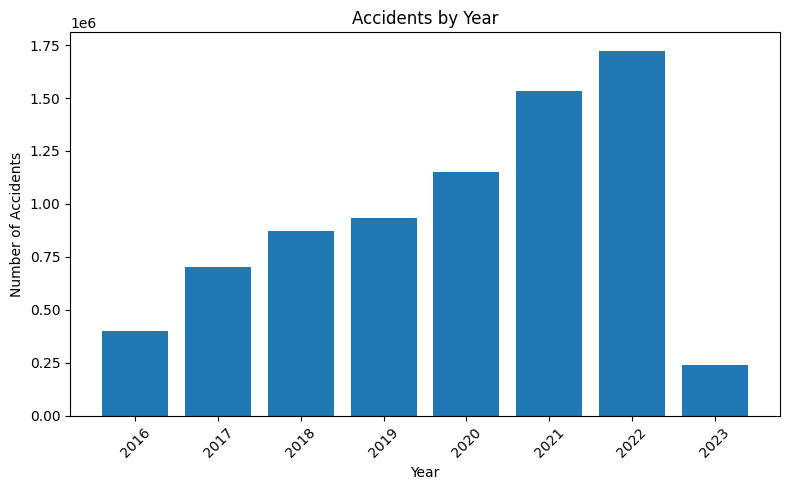

In [0]:
year_df = (
    df.groupBy("accidentYear")
      .count()
      .orderBy("accidentYear")
)

year_pd = year_df.toPandas()

plt.figure(figsize=(8,5))
plt.bar(year_pd["accidentYear"].astype(str), year_pd["count"])
plt.title("Accidents by Year")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

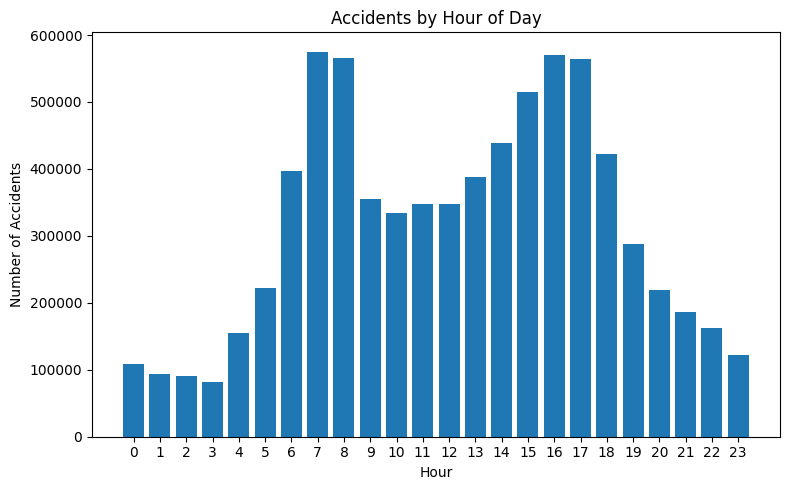

In [0]:
hour_df = (
    df.groupBy("hourOfDay")
      .count()
      .orderBy("hourOfDay")
)

hour_pd = hour_df.toPandas()

plt.figure(figsize=(8,5))
plt.bar(hour_pd["hourOfDay"], hour_pd["count"])
plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

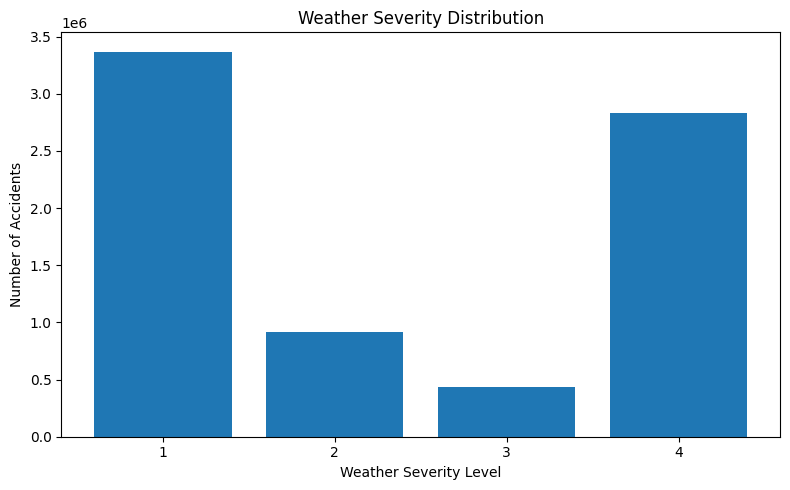

In [0]:
weather_df = (
    df.groupBy("weatherSeverityMapped")
      .count()
      .orderBy("weatherSeverityMapped")
)

weather_pd = weather_df.toPandas()

plt.figure(figsize=(8,5))
plt.bar(weather_pd["weatherSeverityMapped"].astype(str), weather_pd["count"])
plt.title("Weather Severity Distribution")
plt.xlabel("Weather Severity Level")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()

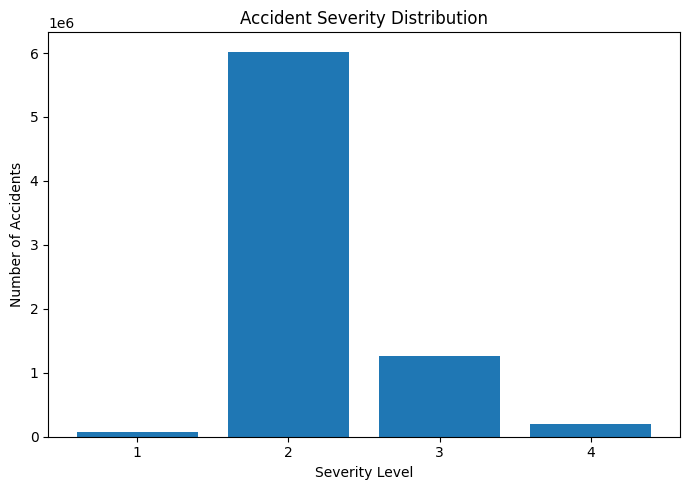

In [0]:
severity_df = (
    df.groupBy("Severity")
      .count()
      .orderBy("Severity")
)

severity_pd = severity_df.toPandas()

plt.figure(figsize=(7,5))
plt.bar(severity_pd["Severity"].astype(str), severity_pd["count"])
plt.title("Accident Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()

In [0]:
print("""
Key Insights:

- Accidents show variation across years, indicating changing traffic patterns.
- Peak accident times occur during specific hours of the day.
- Rush hour contributes significantly to accident frequency.
- Most accidents occur under mild weather conditions.
- Severity distribution is imbalanced, with certain classes dominating.

These observations confirm that temporal and weather features are relevant for prediction.
""")


Key Insights:

- Accidents show variation across years, indicating changing traffic patterns.
- Peak accident times occur during specific hours of the day.
- Rush hour contributes significantly to accident frequency.
- Most accidents occur under mild weather conditions.
- Severity distribution is imbalanced, with certain classes dominating.

These observations confirm that temporal and weather features are relevant for prediction.

